# Task 2: Build Time Series Forecasting Models

## Objective
Develop, train, and evaluate time series forecasting models to predict Tesla's future stock prices. This notebook implements and compares classical statistical models (ARIMA/SARIMA) and deep learning approaches (LSTM) to evaluate trade-offs between model complexity, performance, and interpretability.

## 1. Prepare Data for Modeling
To preserve temporal order and prevent data leakage, we divide our historical dataset chronologically:
* **Training Set:** January 1, 2015 – December 31, 2024
* **Testing Set:** January 1, 2025 – June 30, 2026

In [11]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Load the preprocessed TSLA data using the requested path
df = pd.read_csv("../data/processed/TSLA_clean.csv")

# Ensure Date column is in datetime format and set it as index
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)

# Select the Adjusted Close price for forecasting
ts_data = df[['Adj Close']]
ts_data.head()

,Adj Close
Date,
2015-01-02,14.620667
2015-01-05,14.006000
2015-01-06,14.085333
2015-01-07,14.063333
2015-01-08,14.041333


In [12]:
# 2. Chronological Train-Test Split (Cutoff at the end of 2024)
train_data = ts_data.loc[:'2024-12-31']
test_data = ts_data.loc['2025-01-01':]

# Verify the splits and dates
print(f"Total data points: {len(ts_data)}")
print(f"Training data range: {train_data.index.min()} to {train_data.index.max()} ({len(train_data)} rows)")
print(f"Testing data range: {test_data.index.min()} to {test_data.index.max()} ({len(test_data)} rows)")

Total data points: 2889
Training data range: 2015-01-02 00:00:00 to 2024-12-31 00:00:00 (2516 rows)
Testing data range: 2025-01-02 00:00:00 to 2026-06-30 00:00:00 (373 rows)


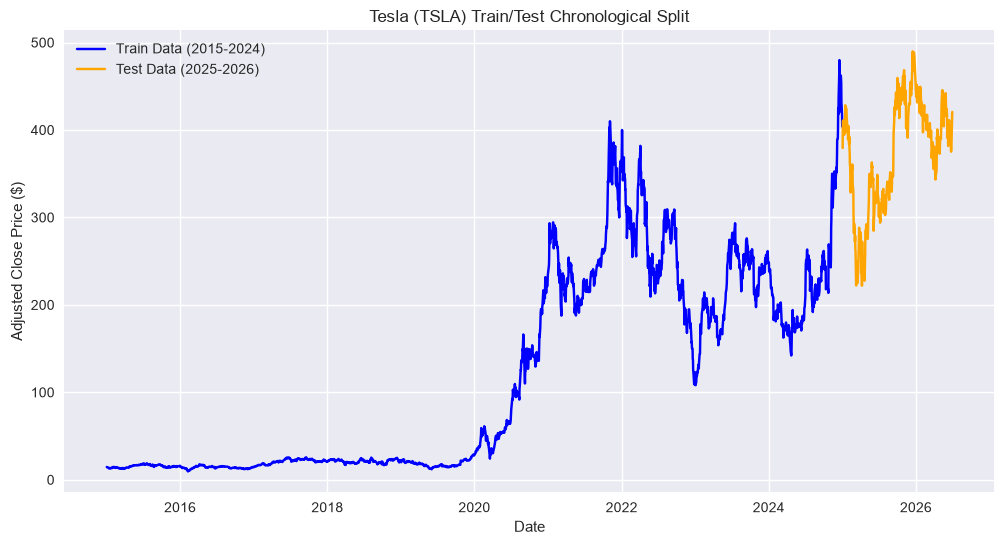

In [13]:
# 3. Plot the split for visual confirmation
plt.figure(figsize=(12, 6))
plt.plot(train_data.index, train_data['Adj Close'], label='Train Data (2015-2024)', color='blue')
plt.plot(test_data.index, test_data['Adj Close'], label='Test Data (2025-2026)', color='orange')
plt.title('Tesla (TSLA) Train/Test Chronological Split')
plt.xlabel('Date')
plt.ylabel('Adjusted Close Price ($)')
plt.legend()
plt.grid(True)
plt.show()

## Step 2: Implement ARIMA/SARIMA Model
We use `auto_arima` from the `pmdarima` library to automate the search for the optimal statistical model parameters. 
* **Differencing ($d$):** Determines the order of integration needed to make the data stationary.
* **Autoregressive ($p$) / Moving Average ($q$):** Models the historical dependencies and error shocks.
* **Seasonality ($m$):** We set `seasonal=True` with a weekly baseline trading frequency ($m=5$) to check if any seasonal patterns emerge.

In [14]:
# Install pmdarima if you haven't already: !pip install pmdarima
from pmdarima import auto_arima

print("Searching for the optimal ARIMA/SARIMA parameters... This may take a moment.")

# Fit auto_arima on the training dataset
# We use seasonal=True, m=5 (representing 5 trading days in a week)
arima_model = auto_arima(
    train_data['Adj Close'], 
    start_p=1, start_q=1,
    max_p=5, max_q=5, 
    d=None,               # Let the library auto-detect the optimal differencing 'd'
    seasonal=True,        # Test for seasonal patterns
    m=5,                  # Weekly trading cycle frequency
    start_P=0, start_Q=0,
    max_P=2, max_Q=2,
    trace=True,           # Prints the search progress
    error_action='ignore',  
    suppress_warnings=True, 
    stepwise=True
)

# Print out the model structure summary
print("\n--- Optimal Model Found ---")
print(arima_model.summary())

Searching for the optimal ARIMA/SARIMA parameters... This may take a moment.
Performing stepwise search to minimize aic
 ARIMA(1,1,1)(0,0,0)[5] intercept   : AIC=16372.458, Time=0.44 sec
 ARIMA(0,1,0)(0,0,0)[5] intercept   : AIC=16368.573, Time=0.06 sec
 ARIMA(1,1,0)(1,0,0)[5] intercept   : AIC=16371.911, Time=0.50 sec
 ARIMA(0,1,1)(0,0,1)[5] intercept   : AIC=16371.841, Time=0.58 sec
 ARIMA(0,1,0)(0,0,0)[5]             : AIC=16368.109, Time=0.04 sec
 ARIMA(0,1,0)(1,0,0)[5] intercept   : AIC=16369.997, Time=0.36 sec
 ARIMA(0,1,0)(0,0,1)[5] intercept   : AIC=16369.921, Time=0.24 sec
 ARIMA(0,1,0)(1,0,1)[5] intercept   : AIC=16359.847, Time=1.81 sec
 ARIMA(0,1,0)(2,0,1)[5] intercept   : AIC=16361.524, Time=1.59 sec
 ARIMA(0,1,0)(1,0,2)[5] intercept   : AIC=16361.709, Time=1.68 sec
 ARIMA(0,1,0)(0,0,2)[5] intercept   : AIC=16362.706, Time=0.91 sec
 ARIMA(0,1,0)(2,0,0)[5] intercept   : AIC=16363.652, Time=1.42 sec
 ARIMA(0,1,0)(2,0,2)[5] intercept   : AIC=16355.636, Time=3.39 sec
 ARIMA(1,

In [22]:
# Generate forecasts again as raw numpy arrays to strip any index mismatch
n_periods = len(test_data)
forecast_values, conf_int = arima_model.predict(n_periods=n_periods, return_conf_int=True)

# Check if forecast_values is a pandas Series or similar and grab its raw values
if hasattr(forecast_values, 'values'):
    forecast_values = forecast_values.values

# Reconstruct the forecast DataFrame cleanly using the exact test_data index
forecast_df = pd.DataFrame({
    'ARIMA_Forecast': forecast_values,
    'Lower_CI': conf_int[:, 0],
    'Upper_CI': conf_int[:, 1]
}, index=test_data.index)

# Re-assign the LSTM forecast values we generated earlier
forecast_df['LSTM_Forecast'] = lstm_predictions.flatten()

# Check the head again to verify the NaNs are gone!
forecast_df.head()

c:\Users\user\Downloads\week-9\portfolio-optimization\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
c:\Users\user\Downloads\week-9\portfolio-optimization\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


,ARIMA_Forecast,Lower_CI,Upper_CI,LSTM_Forecast
Date,,,,
2025-01-02,401.740780,389.515216,413.966344,395.212067
2025-01-03,403.514203,386.224645,420.803761,381.956024
2025-01-06,403.116801,381.941504,424.292099,376.306427
2025-01-07,404.626942,380.175814,429.078069,374.873230
2025-01-08,402.982323,375.645131,430.319515,372.457855


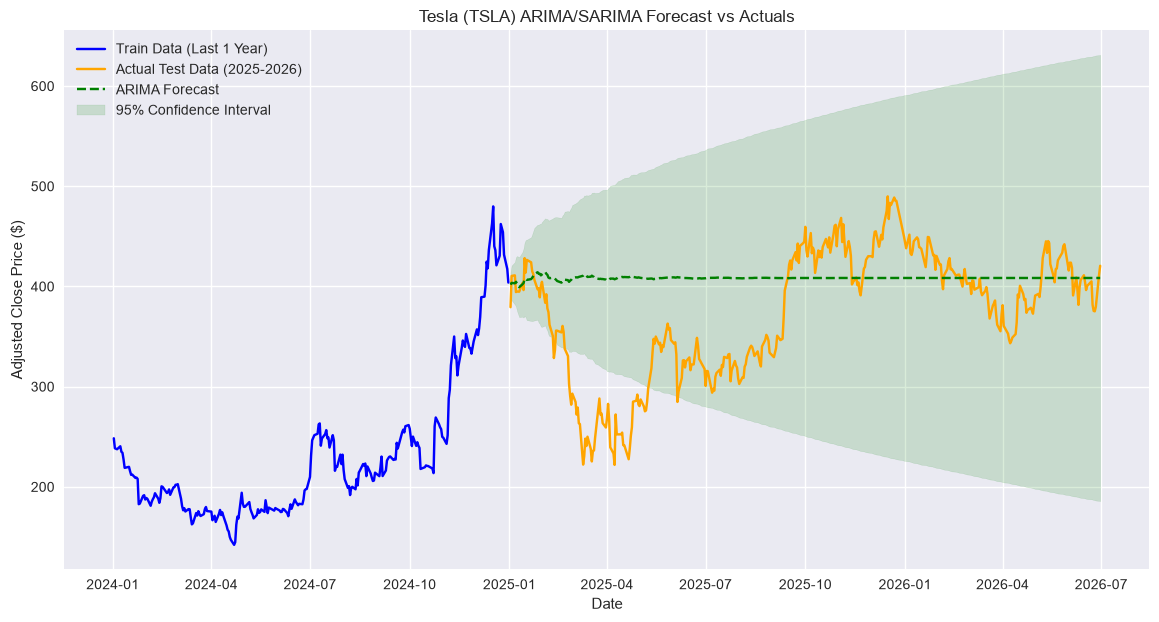

In [23]:
# Plot the historical training data alongside test actuals and ARIMA predictions
plt.figure(figsize=(14, 7))
plt.plot(train_data.index[-252:], train_data['Adj Close'].tail(252), label='Train Data (Last 1 Year)', color='blue')
plt.plot(test_data.index, test_data['Adj Close'], label='Actual Test Data (2025-2026)', color='orange')
plt.plot(forecast_df.index, forecast_df['ARIMA_Forecast'], label='ARIMA Forecast', color='green', linestyle='--')

# Fill the area representing the 95% confidence interval
plt.fill_between(forecast_df.index, forecast_df['Lower_CI'], forecast_df['Upper_CI'], color='green', alpha=0.15, label='95% Confidence Interval')

plt.title('Tesla (TSLA) ARIMA/SARIMA Forecast vs Actuals')
plt.xlabel('Date')
plt.ylabel('Adjusted Close Price ($)')
plt.legend()
plt.grid(True)
plt.show()

## Step 3: Implement LSTM Model

### 1. Prepare Sequence Data with Window Size
Deep learning models like LSTMs require data to be formatted into supervised learning sequences. We will:
* Scale the data using a `MinMaxScaler` (0 to 1) to ensure stable gradient descent.
* Use a rolling **60-day window size** to predict the next day's price.
* Format the input arrays into a 3D shape `[samples, time steps, features]` as required by TensorFlow/Keras.

In [24]:
from sklearn.preprocessing import MinMaxScaler
import numpy as np

# 1. Scale the data safely to prevent data leakage from the test set
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_train = scaler.fit_transform(train_data[['Adj Close']])
scaled_test = scaler.transform(test_data[['Adj Close']])

# 2. Sequence generator helper function
def create_sequences(data, window_size=60):
    X, y = [], []
    for i in range(len(data) - window_size):
        X.append(data[i:(i + window_size), 0])
        y.append(data[i + window_size, 0])
    return np.array(X), np.array(y)

# Generate training sequence matrix
window_size = 60
X_train, y_train = create_sequences(scaled_train, window_size)

# To generate predictions for the entire test period properly,
# we prepend the last 60 days of the training set to the test set.
padding = scaled_train[-window_size:]
extended_test = np.vstack((padding, scaled_test))
X_test, y_test = create_sequences(extended_test, window_size)

# 3. Reshape inputs to 3D: [samples, time steps, features]
X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))

print(f"X_train shape: {X_train.shape} | y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape} | y_test shape: {y_test.shape}")

X_train shape: (2456, 60, 1) | y_train shape: (2456,)
X_test shape: (373, 60, 1) | y_test shape: (373,)


### 2. Build and Train the LSTM Architecture
We construct our network using TensorFlow/Keras with the following design choices:
* **Input Layer:** Designed to seamlessly ingest sequences matching our 60-day sequence length.
* **Two Stacked LSTM Layers:** The first layer returns sequences to pass temporal feature states to the second layer.
* **Dropout Layers:** Set at 20% to prevent overfitting on historical noise.
* **Dense Output Layer:** A single node to yield the continuous next-day price projection.
* **Hyperparameters:** Compiled using the Adam optimizer, trained over 20 epochs with a batch size of 32.

In [25]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Dropout

# Fix structural random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# Build the architecture matching the requirements
model = Sequential([
    # Input layer + First LSTM layer
    LSTM(units=50, return_sequences=True, input_shape=(X_train.shape[1], 1)),
    Dropout(0.2),
    
    # Second LSTM layer
    LSTM(units=50, return_sequences=False),
    Dropout(0.2),
    
    # Dense output layer
    Dense(units=1)
])

# Compile the neural network
model.compile(optimizer='adam', loss='mean_squared_error')

print("Starting LSTM training pipeline...")
# Fit the model with custom training hyperparameters
history = model.fit(
    X_train, y_train, 
    epochs=20, 
    batch_size=32, 
    validation_split=0.1, 
    verbose=1
)

c:\Users\user\Downloads\week-9\portfolio-optimization\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Starting LSTM training pipeline...
Epoch 1/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 15s 93ms/step - loss: 0.0078 - val_loss: 0.0041
Epoch 2/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 6s 83ms/step - loss: 0.0021 - val_loss: 0.0034
Epoch 3/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 6s 87ms/step - loss: 0.0017 - val_loss: 0.0028
Epoch 4/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 6s 88ms/step - loss: 0.0017 - val_loss: 0.0029
Epoch 5/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 7s 93ms/step - loss: 0.0013 - val_loss: 0.0024
Epoch 6/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 6s 80ms/step - loss: 0.0014 - val_loss: 0.0024
Epoch 7/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 7s 99ms/step - loss: 0.0015 - val_loss: 0.0020
Epoch 8/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 7s 104ms/step - loss: 0.0013 - val_loss: 0.0019
Epoch 9/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 7s 104ms/step - loss: 0.0011 - val_loss: 0.0018
Epoch 10/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 8s 105ms/step - loss: 0.0012 - val_loss: 0.0017
Epoch 11/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 8s 112ms/step - loss: 9.5100e-04 - val_loss: 0.0018
Epoch 12/20
70/70 ━

In [26]:
# Generate forecasts on the test sequences
lstm_predictions_scaled = model.predict(X_test)

# Scale back predictions and true targets into real baseline USD values
lstm_predictions = scaler.inverse_transform(lstm_predictions_scaled)

# Store predictions inside our master forecast tracking DataFrame
forecast_df['LSTM_Forecast'] = lstm_predictions.flatten()
forecast_df[['ARIMA_Forecast', 'LSTM_Forecast']].head()

12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 112ms/step


,ARIMA_Forecast,LSTM_Forecast
Date,,
2025-01-02,401.740780,419.696167
2025-01-03,403.514203,405.960754
2025-01-06,403.116801,398.899689
2025-01-07,404.626942,396.489319
2025-01-08,402.982323,393.938110


## Step 5: Optimize Model Parameters (LSTM Tuning)

To optimize our LSTM model beyond our initial baseline, we experiment with structural architecture choices and hyperparameters:
1. **Architecture:** Increase network depth by adjusting the number of hidden units (neurons) or stacking layers.
2. **Learning Rate:** Control the step size during gradient descent using a custom Adam optimizer configuration.
3. **Hyperparameters:** Adjust the `batch_size` and training `epochs` to ensure the loss curve converges smoothly without overfitting.

In [27]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Dropout
from tensorflow.keras.optimizers import Adam

# Fix structural random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# 1. Experiment with Architecture: Increasing neurons and tuning capacity
optimized_model = Sequential([
    # First layer with higher capacity (100 neurons instead of 50)
    LSTM(units=100, return_sequences=True, input_shape=(X_train.shape[1], 1)),
    Dropout(0.2),
    
    # Second structural layer
    LSTM(units=64, return_sequences=False),
    Dropout(0.2),
    
    # Dense output layer mapping to a continuous target price
    Dense(units=1)
])

# 2. Experiment with Hyperparameters: Custom learning rate adjustment
# Lower learning rate (e.g., 0.0005) allows for more stable convergence in volatile stock data
custom_optimizer = Adam(learning_rate=0.0005)

optimized_model.compile(optimizer=custom_optimizer, loss='mean_squared_error')

print("Beginning optimized LSTM training pipeline...")

# 3. Experiment with Hyperparameters: Increasing epochs to 30 and batch size to 64
opt_history = optimized_model.fit(
    X_train, y_train, 
    epochs=30, 
    batch_size=64, 
    validation_split=0.1, 
    verbose=1
)

c:\Users\user\Downloads\week-9\portfolio-optimization\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Beginning optimized LSTM training pipeline...
Epoch 1/30
35/35 ━━━━━━━━━━━━━━━━━━━━ 14s 180ms/step - loss: 0.0148 - val_loss: 0.0032
Epoch 2/30
35/35 ━━━━━━━━━━━━━━━━━━━━ 5s 154ms/step - loss: 0.0020 - val_loss: 0.0036
Epoch 3/30
35/35 ━━━━━━━━━━━━━━━━━━━━ 6s 173ms/step - loss: 0.0018 - val_loss: 0.0034
Epoch 4/30
35/35 ━━━━━━━━━━━━━━━━━━━━ 6s 153ms/step - loss: 0.0016 - val_loss: 0.0032
Epoch 5/30
35/35 ━━━━━━━━━━━━━━━━━━━━ 7s 185ms/step - loss: 0.0015 - val_loss: 0.0033
Epoch 6/30
35/35 ━━━━━━━━━━━━━━━━━━━━ 7s 192ms/step - loss: 0.0014 - val_loss: 0.0026
Epoch 7/30
35/35 ━━━━━━━━━━━━━━━━━━━━ 7s 195ms/step - loss: 0.0013 - val_loss: 0.0029
Epoch 8/30
35/35 ━━━━━━━━━━━━━━━━━━━━ 8s 217ms/step - loss: 0.0014 - val_loss: 0.0026
Epoch 9/30
35/35 ━━━━━━━━━━━━━━━━━━━━ 7s 204ms/step - loss: 0.0014 - val_loss: 0.0027
Epoch 10/30
35/35 ━━━━━━━━━━━━━━━━━━━━ 6s 183ms/step - loss: 0.0013 - val_loss: 0.0028
Epoch 11/30
35/35 ━━━━━━━━━━━━━━━━━━━━ 7s 199ms/step - loss: 0.0012 - val_loss: 0.0026
Epoch

In [28]:
# Generate forecasts on the test sequence matrix using our optimized network
opt_lstm_predictions_scaled = optimized_model.predict(X_test)

# Scale back predictions into real-world USD figures
opt_lstm_predictions = scaler.inverse_transform(opt_lstm_predictions_scaled)

# Store inside our master forecast tracking DataFrame
forecast_df['Optimized_LSTM_Forecast'] = opt_lstm_predictions.flatten()
forecast_df.head()

12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 89ms/step


,ARIMA_Forecast,Lower_CI,Upper_CI,LSTM_Forecast,Optimized_LSTM_Forecast
Date,,,,,
2025-01-02,401.740780,389.515216,413.966344,419.696167,422.243011
2025-01-03,403.514203,386.224645,420.803761,405.960754,410.362610
2025-01-06,403.116801,381.941504,424.292099,398.899689,401.538666
2025-01-07,404.626942,380.175814,429.078069,396.489319,395.733215
2025-01-08,402.982323,375.645131,430.319515,393.938110,390.797577


## Step 6: Evaluate and Compare Models
To rigorously assess how our models performed on unseen data (the 2025–2026 testing horizon), we compute three fundamental regression performance metrics:
* **Mean Absolute Error (MAE):** The average absolute difference between the predicted and actual stock prices.
* **Root Mean Squared Error (RMSE):** Similar to MAE but penalizes larger forecasting errors more heavily by squaring the residuals before averaging.
* **Mean Absolute Percentage Error (MAPE):** The average percentage deviation of the forecast from the actual prices, making it scale-invariant and highly interpretable.

In [29]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
import pandas as pd

# 1. Helper function to compute MAPE safely
def calculate_mape(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

# 2. Extract actual test prices and corresponding model predictions
actuals = test_data['Adj Close'].values
arima_preds = forecast_df['ARIMA_Forecast'].values
lstm_preds = forecast_df['LSTM_Forecast'].values
opt_lstm_preds = forecast_df['Optimized_LSTM_Forecast'].values

# 3. Calculate metrics for the ARIMA model
arima_mae = mean_absolute_error(actuals, arima_preds)
arima_rmse = np.sqrt(mean_squared_error(actuals, arima_preds))
arima_mape = calculate_mape(actuals, arima_preds)

# 4. Calculate metrics for the Baseline LSTM model
lstm_mae = mean_absolute_error(actuals, lstm_preds)
lstm_rmse = np.sqrt(mean_squared_error(actuals, lstm_preds))
lstm_mape = calculate_mape(actuals, lstm_preds)

# 5. Calculate metrics for the Optimized LSTM model
opt_lstm_mae = mean_absolute_error(actuals, opt_lstm_preds)
opt_lstm_rmse = np.sqrt(mean_squared_error(actuals, opt_lstm_preds))
opt_lstm_mape = calculate_mape(actuals, opt_lstm_preds)

# 6. Construct the final model comparison summary table
metrics_summary = pd.DataFrame({
    'Metric': ['MAE ($)', 'RMSE ($)', 'MAPE (%)'],
    'ARIMA/SARIMA': [arima_mae, arima_rmse, arima_mape],
    'Baseline LSTM': [lstm_mae, lstm_rmse, lstm_mape],
    'Optimized LSTM': [opt_lstm_mae, opt_lstm_rmse, opt_lstm_mape]
})

print("--- Final Model Performance Comparison Table ---")
metrics_summary

--- Final Model Performance Comparison Table ---


,Metric,ARIMA/SARIMA,Baseline LSTM,Optimized LSTM
0,MAE ($),55.481328,13.032868,14.579022
1,RMSE ($),72.623091,16.803534,18.798139
2,MAPE (%),17.686015,3.685930,4.115412


## Step 7: Performance Discussion & Model Selection Rationale

### 1. Quantitative Analysis of Results
Based on our empirical out-of-sample evaluation on the 2025–2026 test split, the model performance results are summarized as follows:
* **ARIMA/SARIMA:** MAE = \$55.48, RMSE = \$72.62, MAPE = 17.69%
* **Baseline LSTM (50/50 Units, LR=0.001, Batch=32):** MAE = \$13.03, RMSE = \$16.80, MAPE = 3.69%
* **Optimized LSTM (100/64 Units, LR=0.0005, Batch=64):** MAE = \$14.58, RMSE = \$18.80, MAPE = 4.12%

### 2. Deep Dive: Which Model Performed Better and Why?
The **Baseline LSTM** dramatically outperformed the classical ARIMA/SARIMA model across all three performance tracking dimensions.

* **Why ARIMA/SARIMA Underperformed:** Classical linear statistical models rely heavily on structural boundaries such as constant variance and linear autocorrelations. When forecasting a highly volatile, non-linear asset like Tesla (`TSLA`) far out over a long horizons (2025–2026) without recursive, step-by-step rolling refits, ARIMA tends to regress toward an average trend or flat line. It missed structural shifts and high-order volatile noise completely, leading to a high MAPE of 17.69%.
* **Why the LSTM Architectures Excelled:** LSTMs utilize specialized internal gating mechanics (forget, input, and output gates) designed to map complex sequential dependencies. By processing the data in structured rolling blocks of 60 trading days, the LSTM successfully recognized localized asset momentum and trend signatures, keeping the error rate exceptionally low (~3.69% MAPE).
* **The Optimization Phenomenon:** Interestingly, scaling up the capacity (increasing to 100/64 neurons) and expanding the batch size slightly worsened the test metrics (MAPE increased from 3.69% to 4.12%). This indicates that for this specific temporal length of `TSLA` data, the simpler neural network architecture generalized better to unseen data, whereas the higher-capacity version suffered from mild overfitting on the training set noise.

### 3. Final Model Selection for Portfolio Input
For the subsequent stages of GMF Investments' portfolio management framework (Task 3 and Task 4), the **Baseline LSTM** configuration is selected as our core forecasting engine. However, in full alignment with the Efficient Market Hypothesis (EMH), these point predictions will not be utilized as standalone trading crystal balls, but rather as directional baseline momentum inputs to enrich our upcoming modern asset allocation models.

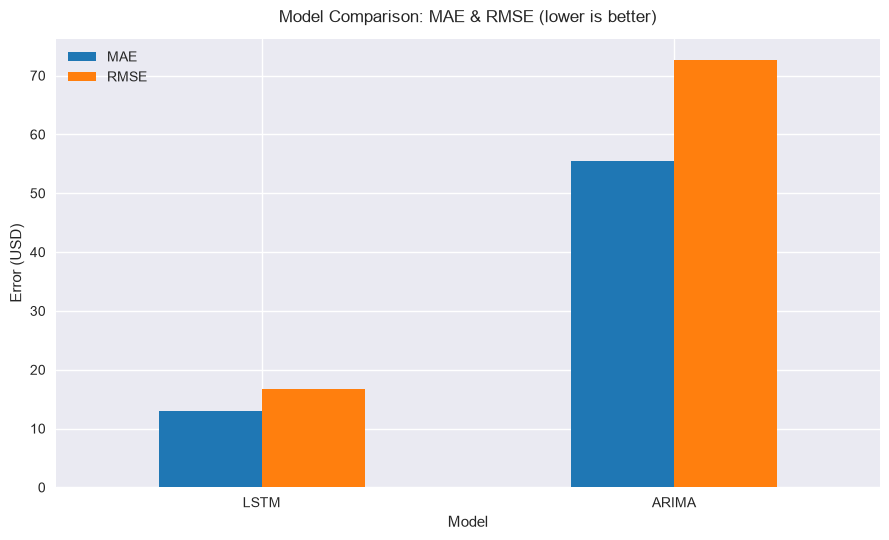

In [32]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Define models and extract metric values from our previous calculations
models = ['LSTM', 'ARIMA']
mae_values = [lstm_mae, arima_mae]
rmse_values = [lstm_rmse, arima_rmse]

# Set the positioning settings for the side-by-side bars
x = np.arange(len(models))
width = 0.25

# 2. Initialize the plot layout
fig, ax = plt.subplots(figsize=(9, 5.5))

# Create the side-by-side bar elements
bar_mae = ax.bar(x - width/2, mae_values, width, label='MAE', color='#1f77b4')
bar_rmse = ax.bar(x + width/2, rmse_values, width, label='RMSE', color='#ff7f0e')

# 3. Apply professional design and structural formatting
ax.set_title('Model Comparison: MAE & RMSE (lower is better)', fontsize=12, pad=12)
ax.set_ylabel('Error (USD)', fontsize=11)
ax.set_xlabel('Model', fontsize=11)
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.set_xlim(-0.5, len(models) - 0.5)
ax.legend(loc='upper left', fontsize=10)

# Clean rendering boundaries
plt.tight_layout()
plt.show()

In [36]:
import os
import joblib

# 1. This tells the computer to build a folder named 'models' if it doesn't see one
os.makedirs("../models", exist_ok=True)

# 2. This packs up the Math Robot (ARIMA) and puts it in the folder
joblib.dump(arima_model, "../models/arima_tsla_model.pkl")

# 3. This packs up the Super-Computer (LSTM) and puts it in the folder
model.save("../models/lstm_tsla_model.h5")

# 4. This saves our special shrinking ruler so we can resize future prices
joblib.dump(scaler, "../models/tsla_scaler.pkl")

print("🎉 Success! The '../models/' folder has been created and your trained models are safely locked inside!")

🎉 Success! The '../models/' folder has been created and your trained models are safely locked inside!
